# project specific functions

In [ ]:
def load_standard_packages():
    """
    imports os, numpy, pandas, matplotlib, and modelbase. 
    Sets up warnings to show once per cell run.
    Prints the version of modelbase.
    """

    # basics
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import importlib

    import warnings
    warnings.filterwarnings("once")  # Ensures warnings appear on every cell run
    #warnings.simplefilter("once")
    #warnings.simplefilter("error") #handle warnings as errors (used for DepreactionWarnings)
    #warnings.simplefilter("default")

    # modelbase
    import modelbase
    from modelbase.ode import Simulator
    from scipy import integrate

    print(importlib.metadata.version("modelbase"))

    globals().update(locals())

In [ ]:
def debug_this(variable_name, variable=None, debug=True):
    if not debug:
        return

    # Handle list/tuple input
    if isinstance(variable_name, (list, tuple)) and isinstance(variable, (list, tuple)):
        if len(variable_name) != len(variable):
            raise ValueError("Length of variable_name and variable must match.")
        for name, val in zip(variable_name, variable):
            print(f"\t\t!!!{name}!!!\n{val}\n")
    else:
        print(f"\t\t!!!{variable_name}!!!\n{variable}\n")


In [ ]:
def change_wordir():
    """Change working dir to parent if 'models' folder is not present."""

    import os

    if "models" not in os.listdir():
        os.chdir("..")

In [ ]:
def checkpoint(object_name, dir: str = "", filename: str = "", p_dir: str = "pickles/", overwrite=False):
    """
    Save or load a Python object using joblib, based on its name as a string.
    
    If the object with the given name exists in the global scope:
        - If the file does not exist, it is saved.
        - If the file exists and overwrite is True, it is overwritten (and a backup created)
        - If the file exists and overwrite is False, a warning is issued.
    
    If the object does not exist in the global scope:
        - It is loaded from the file if it exists.
        - If the file does not exist, a warning is raised.
    """
    import os
    import joblib
    import warnings
    import inspect
    import shutil

    if filename == "":
        filename = object_name
    filename += ".joblib"

    frame = inspect.currentframe().f_back
    final_dir = os.path.join(p_dir, dir)
    os.makedirs(final_dir, exist_ok=True)

    file_path = os.path.join(final_dir, filename)
    backup_path = os.path.join(final_dir, f"backup_{filename}")

    if object_name in frame.f_globals:
        obj = frame.f_globals[object_name]
        if os.path.exists(file_path):
            if overwrite:
                shutil.copy2(file_path, backup_path) # make a backup of the file
                joblib.dump(obj, file_path)
                print(f"Overwritten: {file_path},  (backup created at {backup_path})")
            else:
                warnings.warn(f"File already exists and will not be overwritten: {file_path}")
        else:
            joblib.dump(obj, file_path)
            print(f"Saved: {file_path}")
    else:
        if os.path.exists(file_path):
            obj = joblib.load(file_path)
            print(f"Loaded: {file_path}")
        else:
            warnings.warn(f"Object '{object_name}' not found and no saved file exists at: {file_path}")
            obj = None
    return obj

In [ ]:
def load_model(model_name):
    """Assuming that the model is in the models folder, and that the cwd is not "analyses"."""

    path_to_model = f"models.{model_name}"  # Convert path to importable module format
    model_module = importlib.import_module(path_to_model) # Dynamically import the module    
    get_model = getattr(model_module, "get_model") # Access the function/class from the module

    m = get_model()
    print(f"\nsuccesfully loaded {model_name} :D")
    return m


In [ ]:
def get_stst_y0(model_or_simulator, pfd=800, old_y0 = None):
    """
    Returns the initial conditions for the model.
    The values are based on the original model and need to be adjusted for each new model.
    Therefore we quickly simulate the model to steady state.
    """

    # If the model does not contain the metabolites in the first y0, it will ignore them.
    if not old_y0:
        old_y0 = {
            'PQ': np.float64(7.9748184613444275),
            'PC': np.float64(3.57108813007692),
            'Fd': np.float64(1.721696341225566),
            'ATP': np.float64(1.8936718777506976),
            'NADPH': np.float64(0.6788108516140969),
            'H': np.float64(0.004802502492550202),
            'LHC': np.float64(0.6969473105113153),
            'Psbs': np.float64(0.7674559928090664),
            'Vx': np.float64(0.33370273249937626),
            'PGA': np.float64(1.35339320630429),
            'BPGA': np.float64(0.001210512840897971),
            'GAP': np.float64(0.01575251285636341),
            'DHAP': np.float64(0.346555191748089),
            'FBP': np.float64(0.03875970146177038),
            'F6P': np.float64(1.7636781722849098),
            'G6P': np.float64(4.056459794959748),
            'G1P': np.float64(0.23527466807499517),
            'SBP': np.float64(0.21539487281695865),
            'S7P': np.float64(0.2980600536159056),
            'E4P': np.float64(0.047810099035570125),
            'X5P': np.float64(0.04881224690913804),
            'R5P': np.float64(0.08176050965246137),
            'RUBP': np.float64(0.5637405774508513),
            'RU5P': np.float64(0.03270420319369181),
            'P700FA': np.float64(1.5773834520316117),
            'P700+FA-': np.float64(0.017015497519751573),
            'P700FA-': np.float64(0.0278690554094764),
            'B0': np.float64(1.9770731028776223),
            'B1': np.float64(9.993346909605244e-08),
            'B2': np.float64(0.5229267163470579),
            'MDA': np.float64(2.827838963821763e-05),
            'H2O2': np.float64(1.651088578343372e-05),
            'DHA': np.float64(1.9875782499986854e-07),
            'GSSG': np.float64(9.64227889697731e-08),
            'TR_ox': np.float64(0.6912357389136846),
            'E_inactive': np.float64(1.467838696087237),
            #"GSH": 9.999999998752703,
            # #"ASC": 9.999997726884683
            'dpsi': np.float64(31/1e6)
        }

    if not isinstance(model_or_simulator, modelbase.ode.simulators.simulator._Simulate):
        sim4_new_y0 = Simulator(model_or_simulator)
    else:
        sim4_new_y0 = model_or_simulator

    sim4_new_y0.initialise(old_y0)

    sim4_new_y0.update_parameter("pfd", pfd)

    sim4_new_y0.simulate_to_steady_state()

    st_st_y0 = sim4_new_y0.get_new_y0()

    if not st_st_y0:
        print("Unable to generate new initial conditions! Default y0 returned!")
        return old_y0
    else:
        return st_st_y0

# plotting

In [ ]:
def shade_light(c, axs, light_column_name_in_c = "L", min_alpha=0.05, max_alpha=0.2):
    """
    Lower PFD -->  darker shading
    1) log1p (PFD values) to avoid extreme values
    2) normalize to [0, 1]
    3) linearly map to a bounded alpha range [min_alpha, max_alpha] to avoid over-darkening

    Parameters:
    - c: DataFrame with a column 'L' containing PFD values and a time-based index
    - axs: Single axis or iterable of axes to shade

    Returns:
    - List of strings describing shading spans for debugging
    """
    if not isinstance(axs, (list, tuple, np.ndarray)):
        axs = [axs]
    lights = c[light_column_name_in_c]
    eps = 1e-6  # prevent log(0)
    transformed = np.log1p(lights + eps)
    normed = (transformed - transformed.min()) / (transformed.max() - transformed.min() + eps)

    group_id = (lights != lights.shift()).cumsum()
    grouped = c.groupby(group_id)

    prev_end = None  # to track and make the next shading start where the last one ended
    for ax in axs:
        prev_end = None  # reset for each axis!
        for _, group in grouped:
            t_start = group.index[0] if prev_end is None else prev_end
            t_end, idx = group.index[-1], group.index[0]
            alpha = min_alpha + (1 - normed.loc[idx]) * (max_alpha - min_alpha)
            ax.axvspan(t_start, t_end, color=(0, 0, 0, alpha), linewidth=0)
            prev_end = t_end

In [ ]:
def colourblind_palette(source: str = "seaborn", plot = True):
    if source == "seaborn":
        import seaborn as sns
        colors = list(sns.color_palette("colorblind").as_hex())
        colours = dict(zip(["blue", "orange", "green", "red", "purple", "beige", "pink", "gray", "yellow", "skyblue"], colors))

    elif source == "matplotlib":
        import matplotlib.pyplot as plt
        colors = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])
        colours = dict(zip(["blue", "orange", "green", "pink", "purple", "red", "brown", "grey", "lightgreen", "skyblue"], colors))

    elif source == "own":
        colors = ["#6AA7DE", "#FF7F00", "#2E7D47", "#F58BB2", "#8F3FBF", "#E41A1C", "#704214", "#8A8A8A"]
        colours = dict(zip(["blue", "orange", "green", "pink", "purple", "red", "brown", "grey"], colors))
    else:
        raise ValueError("source must be 'seaborn', 'matplotlib' or 'own'")

    return(colors, colours)

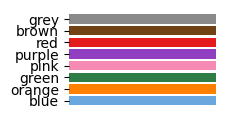

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# color_names, color_dict = colourblind_palette(source="own")

# fig, ax = plt.subplots(figsize=(2,1.3))
# ax.barh(color_names, [1] * len(color_names), color=[color_dict[name] for name in color_dict.keys()],)
# ax.set_xticks([])
# ax.set_yticks(range(len(color_dict.keys())))
# ax.set_yticklabels(color_dict.keys(), fontsize=10)
# ax.set_frame_on(False)

# plt.show()

In [ ]:
def save_fig(fig, model, analysis, name, close_fig=True):
    import shutil
    import os

    if fig is None:
        fig = plt.gcf()
        if not fig.axes:
            raise ValueError("No figure to save — either pass a fig or ensure one is plotted.")


    if isinstance(model, list):
        if len(model) == 1:
            model = model[0]
        else:
            model_names = "_".join(model)
            model = "comp"
            name = f"{name}__{model_names}"

    folder = f"figures/{model}/{analysis}/"
    os.makedirs(folder, exist_ok=True)
    
    path = f"{folder}{name}.png"
    backup_path = f"{folder}Z_backup_{name}.png"
    
    if os.path.exists(path):
        shutil.copy2(path, backup_path)
        print(f"existing figure backed up to {backup_path}")
    
    fig.savefig(path, pad_inches=0.1, bbox_inches="tight")
    if close_fig:
        plt.close(fig)
    print(f"saved figure to {path}")


In [ ]:
########################
### COLLECT METADATA ###
########################

# import platform
# import sys
# import subprocess
# import json

# def get_python_version():
#     return sys.version

# def get_installed_packages():
#     try:
#         import pkg_resources
#         return sorted(["{}=={}".format(i.key, i.version) for i in pkg_resources.working_set])
#     except ImportError:
#         return subprocess.check_output([sys.executable, '-m', 'pip', 'freeze']).decode().splitlines()

# def get_os_info():
#     return {
#         "system": platform.system(),
#         "release": platform.release(),
#         "version": platform.version(),
#         "machine": platform.machine(),
#         "processor": platform.processor(),
#     }

# def get_vscode_version():
#     try:
#         output = subprocess.check_output(['code', '--version']).decode().splitlines()
#         return output[0] if output else "Unknown"
#     except Exception:
#         return "VS Code not found or not in PATH"

# def get_git_info():
#     try:
#         commit = subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode().strip()
#         branch = subprocess.check_output(['git', 'rev-parse', '--abbrev-ref', 'HEAD']).decode().strip()
#         return {"branch": branch, "commit": commit}
#     except Exception:
#         return "Git repo not detected"

# def collect_metadata():
#     return {
#         "python_version": get_python_version(),
#         "os_info": get_os_info(),
#         "vscode_version": get_vscode_version(),
#         "git_info": get_git_info(),
#         "installed_packages": get_installed_packages()
#     }

# # Print as nicely formatted JSON
# if __name__ == "__main__":
#     print(json.dumps(collect_metadata(), indent=2))
